# 식수 인원 예측 성능 향상 (V4)

이 버전에서는 다음을 수행합니다:
1. **기상 데이터 통합**: `weather1.csv` ~ `weather5.csv` 데이터를 병합하여 기온, 강수량 등 정보를 추가합니다.
2. **시각화 강화**: 기상 상태가 식수 인원에 미치는 영향을 분석합니다.
3. **앙상블 모델링**: XGBoost, LightGBM, CatBoost 모델을 결합하여 예측 성능을 극대화합니다.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import korean_font
korean_font.set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 로드 및 병합

In [9]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

# 기상 데이터 로드 및 병합
weather_dfs = []
for i in range(1, 6):
    path = f'data/weather{i}.csv'
    # 일반적으로 공공데이터는 cp949 인코딩인 경우가 많습니다.
    temp_df = pd.read_csv(path, encoding='cp949')
    weather_dfs.append(temp_df)

weather = pd.concat(weather_dfs, axis=0).reset_index(drop=True)

# 컬럼명 정리 (깨진 한글 정리)
weather.columns = ['지점', '지점명', '일시', '기온', '강수량', '풍속', '습도', '일사량', '적설', '전운량', '지면온도']

# 날짜 타입 변환
train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])
weather['일시'] = pd.to_datetime(weather['일시'])

# 데이터 병합
train = pd.merge(train, weather, left_on='일자', right_on='일시', how='left')
test = pd.merge(test, weather, left_on='일자', right_on='일시', how='left')

print("Train shape (after merge):", train.shape)
print("Test shape (after merge):", test.shape)

Train shape (after merge): (1208, 23)
Test shape (after merge): (50, 21)


## 2. 데이터 전처리 및 EDA

In [10]:
# 결측치 처리
train['강수량'] = train['강수량'].fillna(0)
test['강수량'] = test['강수량'].fillna(0)
train['적설'] = train['적설'].fillna(0)
test['적설'] = test['적설'].fillna(0)

# 기타 기상 데이터 평균값 등으로 채우기
weather_cols = ['기온', '풍속', '습도', '일사량', '전운량', '지면온도']
for col in weather_cols:
    train[col] = train[col].fillna(train[col].mean())
    test[col] = test[col].fillna(train[col].mean())

# 강수 여부 피처
train['is_rain'] = train['강수량'].apply(lambda x: 1 if x > 0 else 0)
test['is_rain'] = test['강수량'].apply(lambda x: 1 if x > 0 else 0)

def process_date(df):
    df['month'] = df['일자'].dt.month
    df['day'] = df['일자'].dt.day
    df['weekday'] = df['일자'].dt.weekday
    return df

train = process_date(train)
test = process_date(test)

def process_personnel(df):
    df['in_office'] = df['본사정원수'] - df['본사휴가자수'] - df['본사출장자수'] - df['현본사소속재택근무자수']
    return df

train = process_personnel(train)
test = process_personnel(test)

### 2.1 시계열 및 기본 통계 시각화
식수 인원의 시간 흐름에 따른 변화와 요일별 패턴을 분석합니다.

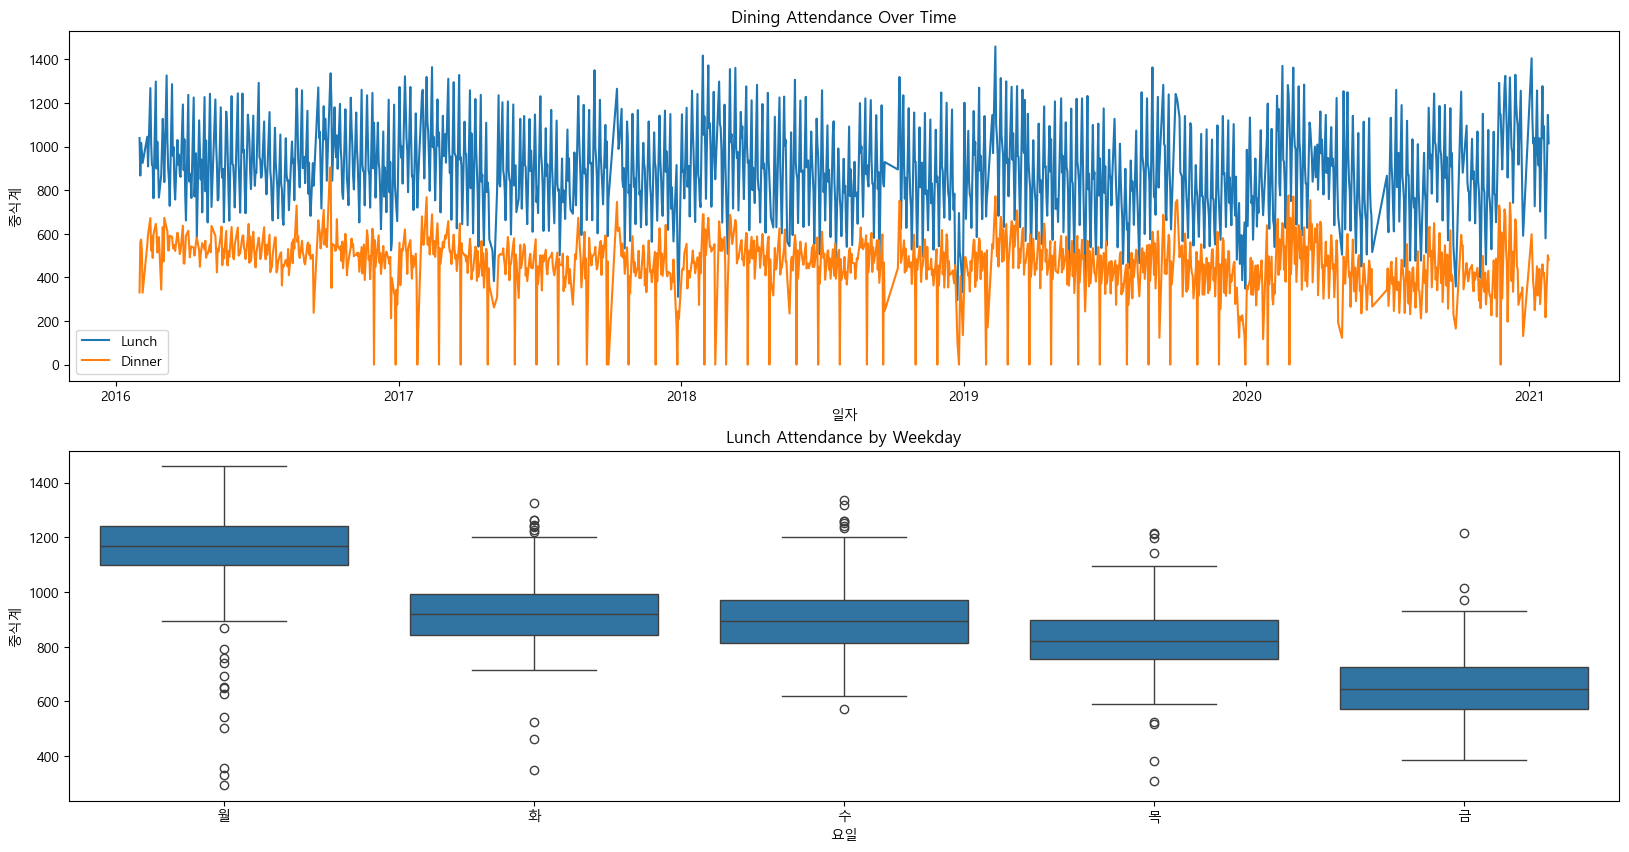

In [11]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 1, 1)
sns.lineplot(data=train, x='일자', y='중식계', label='Lunch')
sns.lineplot(data=train, x='일자', y='석식계', label='Dinner')
plt.title('Dining Attendance Over Time')
plt.legend()

plt.subplot(2, 1, 2)
day_order = ['월', '화', '수', '목', '금']
sns.boxplot(data=train, x='요일', y='중식계', order=day_order)
plt.title('Lunch Attendance by Weekday')
plt.show()

### 2.2 인원수와 식수 인원의 상관관계
실제 출근 인원(`in_office`)과 식수 인원 사이의 관계를 시각화합니다.

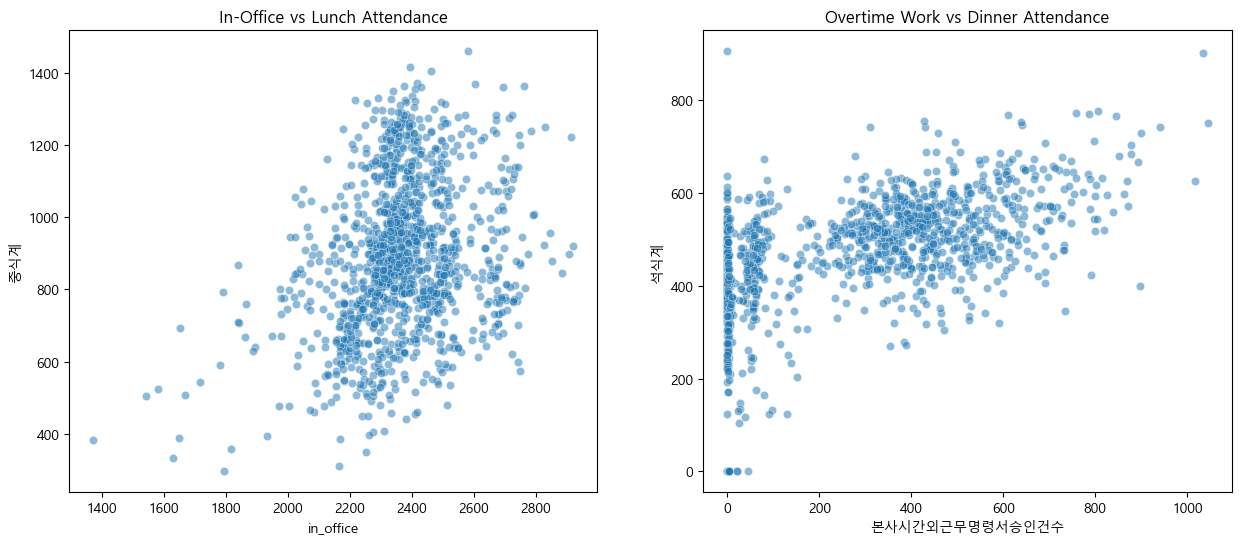

In [12]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=train, x='in_office', y='중식계', alpha=0.5)
plt.title('In-Office vs Lunch Attendance')

plt.subplot(1, 2, 2)
# 석식의 경우 시간외근무명령서승인건수와 관계가 깊은지 확인
sns.scatterplot(data=train, x='본사시간외근무명령서승인건수', y='석식계', alpha=0.5)
plt.title('Overtime Work vs Dinner Attendance')
plt.show()

### 2.3 기상 효과 심층 분석
강수량, 기온 등이 식수 인원에 미치는 영향을 다각도로 분석합니다.

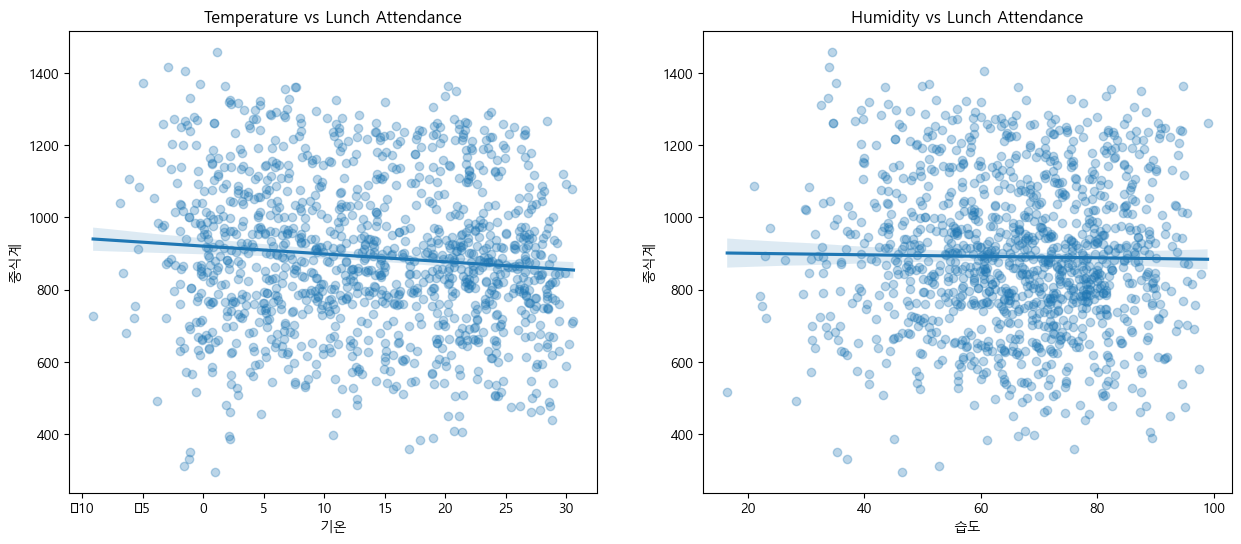

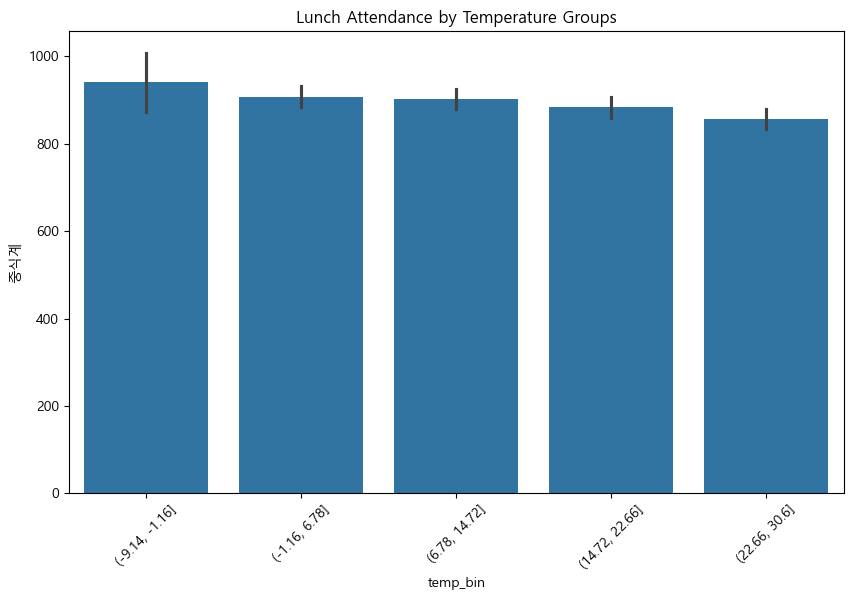

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.regplot(data=train, x='기온', y='중식계', scatter_kws={'alpha':0.3}, ax=axes[0])
axes[0].set_title('Temperature vs Lunch Attendance')

sns.regplot(data=train, x='습도', y='중식계', scatter_kws={'alpha':0.3}, ax=axes[1])
axes[1].set_title('Humidity vs Lunch Attendance')
plt.show()

plt.figure(figsize=(10, 6))
train['temp_bin'] = pd.cut(train['기온'], bins=5)
sns.barplot(data=train, x='temp_bin', y='중식계')
plt.title('Lunch Attendance by Temperature Groups')
plt.xticks(rotation=45)
plt.show()

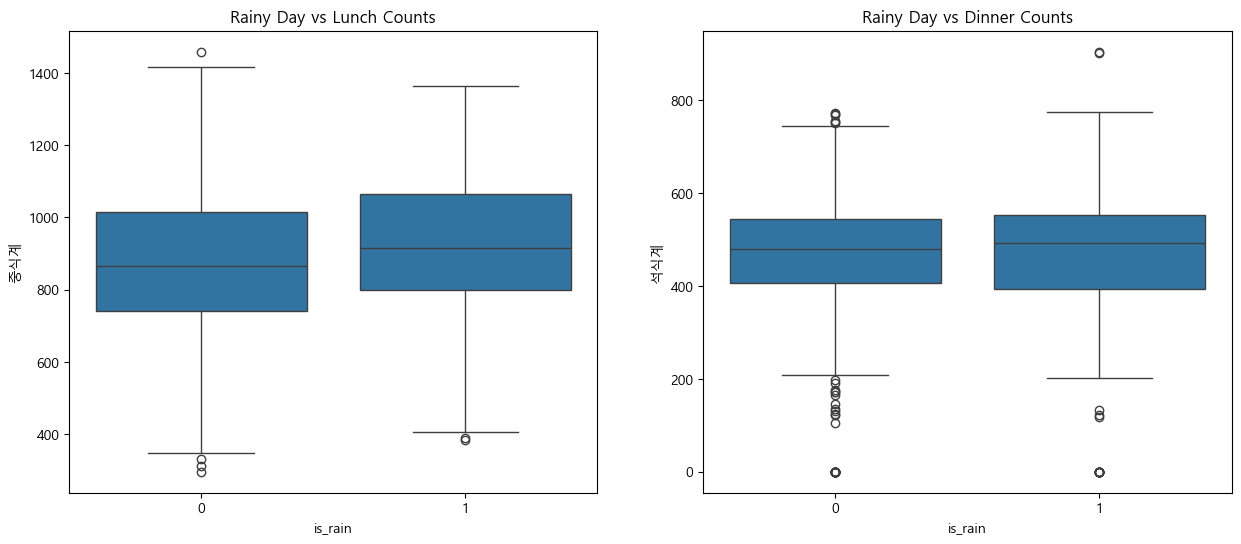

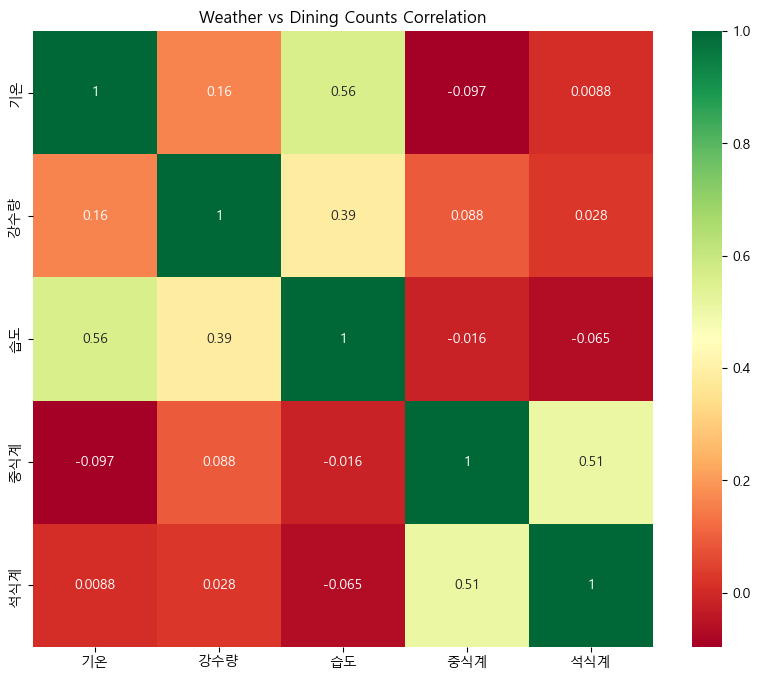

In [14]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='is_rain', y='중식계', data=train)
plt.title('Rainy Day vs Lunch Counts')

plt.subplot(1, 2, 2)
sns.boxplot(x='is_rain', y='석식계', data=train)
plt.title('Rainy Day vs Dinner Counts')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(train[['기온', '강수량', '습도', '중식계', '석식계']].corr(), annot=True, cmap='RdYlGn')
plt.title('Weather vs Dining Counts Correlation')
plt.show()

### 2.2 메뉴 파싱 및 인코딩 (V3 로직 유지)

In [15]:
def parse_menu(menu_series):
    bob, soup, main = [], [], []
    for menu_str in menu_series:
        if pd.isna(menu_str) or menu_str.strip() == '':
            bob.append('None'); soup.append('None'); main.append('None')
            continue
        items = menu_str.split()
        clean_items = [x for x in items if '(' not in x]
        bob.append(clean_items[0] if len(clean_items) > 0 else 'None')
        soup.append(clean_items[1] if len(clean_items) > 1 else 'None')
        main.append(clean_items[2] if len(clean_items) > 2 else 'None')
    return bob, soup, main

train['lunch_bob'], train['lunch_soup'], train['lunch_main'] = parse_menu(train['중식메뉴'])
train['dinner_bob'], train['dinner_soup'], train['dinner_main'] = parse_menu(train['석식메뉴'])
test['lunch_bob'], test['lunch_soup'], test['lunch_main'] = parse_menu(test['중식메뉴'])
test['dinner_bob'], test['dinner_soup'], test['dinner_main'] = parse_menu(test['석식메뉴'])

# 석식 이상치 제거 (V3 로직)
train_dinner = train.copy()
train_dinner = train_dinner[train_dinner['석식메뉴'].str.contains('\*', na=False) == False]
train_dinner = train_dinner[train_dinner['dinner_bob'] != 'None']
train_dinner = train_dinner[train_dinner['석식계'] > 0]

def encode_features(train_df, test_df, cat_cols):
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {l: i for i, l in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(lambda x: mapping.get(x, -1))
    return train_df, test_df

cat_cols = ['lunch_bob', 'lunch_soup', 'lunch_main', 'dinner_bob', 'dinner_soup', 'dinner_main']
train_lunch_encoded, test_lunch_encoded = encode_features(train.copy(), test.copy(), cat_cols)
train_dinner_encoded, test_dinner_encoded = encode_features(train_dinner.copy(), test.copy(), cat_cols)

## 3. 모델링 및 앙상블

In [16]:
features_lunch = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', '기온', '강수량', '습도', 'is_rain', 'lunch_bob', 'lunch_soup', 'lunch_main']
features_dinner = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', '기온', '강수량', '습도', 'is_rain', 'dinner_bob', 'dinner_soup', 'dinner_main']

def train_ensemble(X, y, test_X, target_name):
    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # XGBoost, LightGBM, CatBoost 가중치 앙상블
    models = {
        'xgb': {'model': XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42, early_stopping_rounds=50), 'weight': 0.4},
        'lgbm': {'model': LGBMRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42), 'weight': 0.4},
        'cat': {'model': CatBoostRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42, verbose=0, early_stopping_rounds=50), 'weight': 0.2}
    }
    
    total_test_preds = np.zeros(len(test_X))
    total_oof_preds = np.zeros(len(X))
    
    for name, m_info in models.items():
        name_test_preds = np.zeros(len(test_X))
        name_oof_preds = np.zeros(len(X))
        
        print(f"--- Training {name.upper()} ---")
        for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
            
            model = m_info['model']
            if name == 'lgbm':
                import lightgbm as lgb
                model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='mae', 
                          callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)])
            else:
                model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
                
            name_oof_preds[val_idx] = model.predict(X_va)
            name_test_preds += model.predict(test_X) / n_splits
            
        fold_mae = mean_absolute_error(y, name_oof_preds)
        print(f"{name.upper()} Total MAE: {fold_mae:.4f}")
        
        total_oof_preds += name_oof_preds * m_info['weight']
        total_test_preds += name_test_preds * m_info['weight']
        
    print(f"{target_name} Ensemble OOF MAE: {mean_absolute_error(y, total_oof_preds):.4f}\n")
    return total_test_preds

print("--- 중식계 앙상블 학습 ---")
target_lunch = train.columns[10]
preds_lunch = train_ensemble(train_lunch_encoded[features_lunch], train_lunch_encoded[target_lunch], test_lunch_encoded[features_lunch], "중식계")

print("--- 석식계 앙상블 학습 ---")
target_dinner = train.columns[11]
preds_dinner = train_ensemble(train_dinner_encoded[features_dinner], train_dinner_encoded[target_dinner], test_dinner_encoded[features_dinner], "석식계")

--- 중식계 앙상블 학습 ---
--- Training XGB ---
XGB Total MAE: 79.7316
--- Training LGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1548
[LightGBM] [Info] Number of data points in the train set: 966, number of used features: 12
[LightGBM] [Info] Start training from score 891.366460
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## 4. 최종 예측 리포트 및 저장

In [17]:
submission['중식계'] = preds_lunch
submission['석식계'] = preds_dinner

submission.to_csv('submission/dining_submission_v4.csv', index=False)
print("제출 파일이 submission/dining_submission_v4.csv 에 저장되었습니다.")
display(submission.head())

제출 파일이 submission/dining_submission_v4.csv 에 저장되었습니다.


,일자,중식계,석식계
0,2021-01-27,898.349764,324.663635
1,2021-01-28,874.142765,479.235866
2,2021-01-29,652.079628,263.014566
3,2021-02-01,1241.504942,506.092984
4,2021-02-02,1051.794806,492.844247
